## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

In [14]:
## Define & Measure
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "garrettspringsted"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("/content/STAT-7110-Quality-Control/Assignments/HW1")
getwd()
list.files()


[1] "/content/STAT-7110-Quality-Control/Assignments/HW1"

[1] "FilamentDiameter_PhaseI.xlsx"  "FilamentDiameter_PhaseII.xlsx"
[3] "STAT-7110-HW1.ipynb"           "STAT-7110-Quality-Control"


     
### Q1: Briefly describe the purpose of this analysis

## A1: The purpose of this analysis is to examine the filament diameter made by Extruder Line 3 and determine whether the manufacturing process is operating in a state of statistical control. I want to evaluate the mean and standard deviation to locate any potential sources of variation that point to factors that may be the cause of customer complaints.




### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.

## A2: The quality characteristics the team will monitor is the filament diameter produced by Extruder Line 3. The filament is measured in millimeters(mm).Measured inline by a laser micrometer as each spool is produced. The diameter is treated as a continuous, normally-distributed quality characteristic.



### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

## A3: The $\bar{X}$ and $R/s$ charts are appropriate in this scenario because the filament diameter is a continuous variable and we are wanting to follow the process location and process variablity. The $\bar{X}$ monitors process means and it staying where it should be. The $R/s$ chart monitors the spread of the process and it's stability. Limitations include the assumption that the underlying process follows a normal distribution. The Xbar is fairly robust to milder moderate departures from normality. The R chart is more sensitive to non-normality.



## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.
## A4 ## The estimated process mean for both $R$ and $s$ in Phase 1 is 1.754017 mm. Using the $R$ method the estimated standard deviation is 0.01144864 mm. Using the $s$ method the estimated standard deviation is also 0.01154485 mm.

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


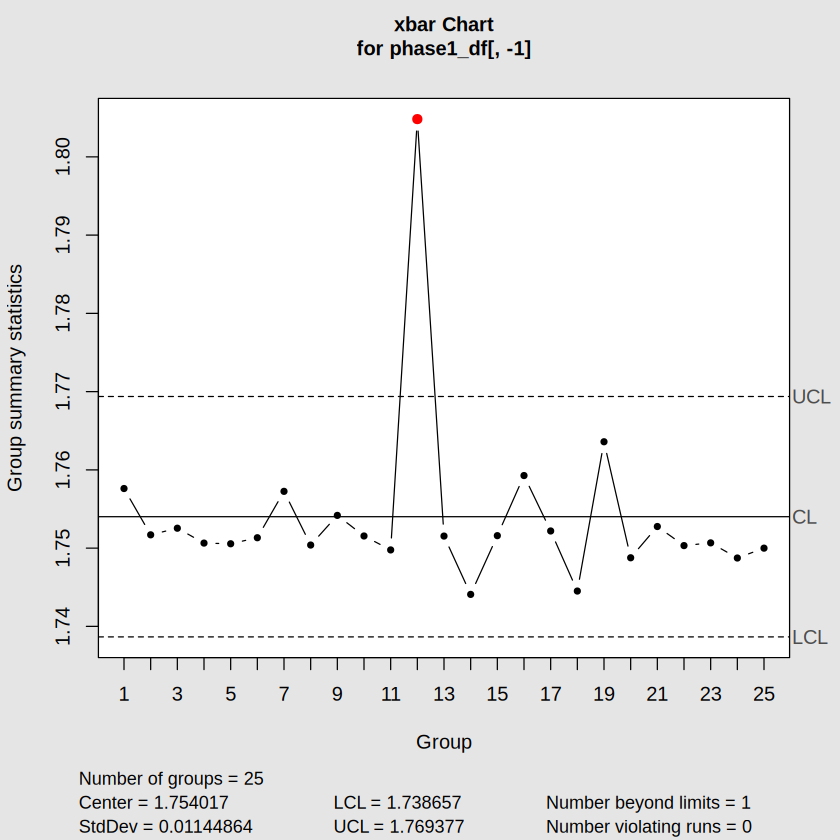

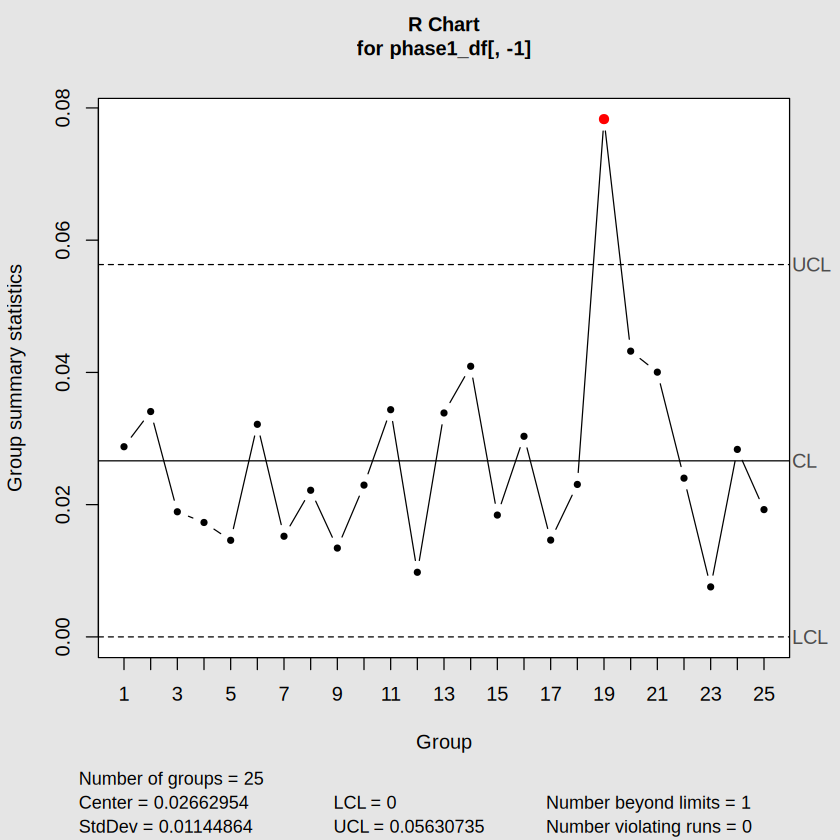

[1] 1.754017

[1] 0.01144864

[1] 1.754017

[1] 0.01154485

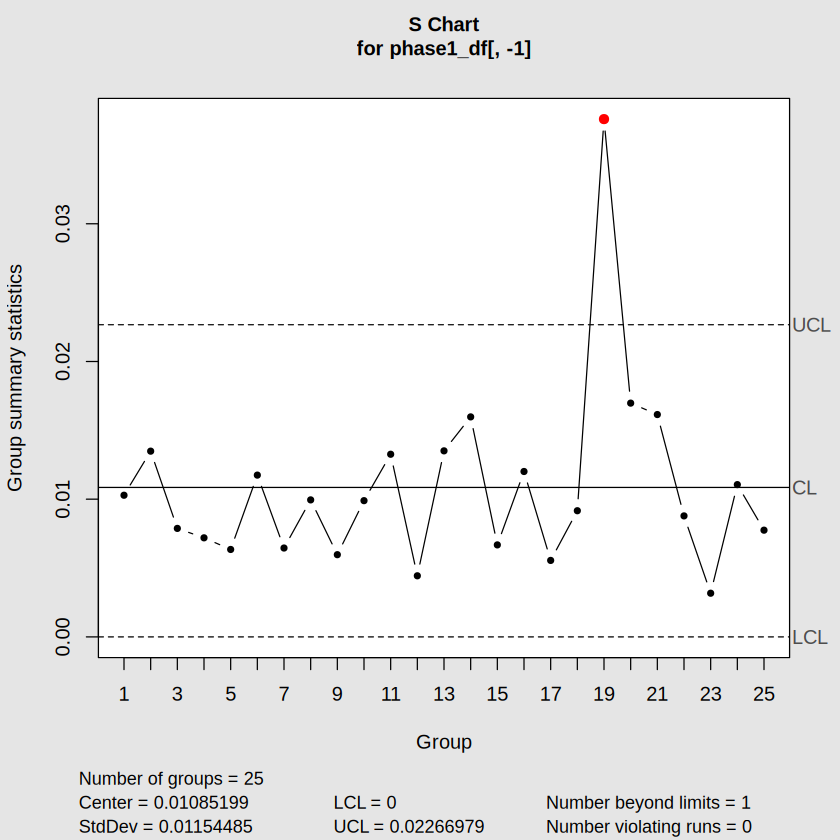

In [16]:
## Read in Phase 1 Data ##
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

phase1_df<- read_excel("FilamentDiameter_PhaseI.xlsx")

## Data Check ##
phase1_df|> glimpse()

## Xbar ##

phase1_xbar<- qcc(phase1_df[,-1],
                  type= "xbar",
                  plot=TRUE)

## R-Chart ##
phase1_r<- qcc(phase1_df[,-1],
                  type= "R",
                  plot=TRUE)

##S-Chart ##
phase1_s<- qcc(phase1_df[,-1],
                  type= "S",
                  plot=TRUE)
## R Method ##
phase1_xbar$center
phase1_r$std.dev


##S Method##
phase1_xbar$center
phase1_s$std.dev


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

## A5: Subgroup 19 appears to be above the UCL of 0.05630735. This indicates high variablity in the diameter of the filament in that Subgroup. One possible reason for this observation may be from poor or inconsistent performance of the ageing heating element on Extruder Line 3. This may be contributing to the poor consistency with the filament diamter. After removing Subgroup 19 and replotting the chart, all of the remaining Subgroups fall with the UCL(0.05175418) and LCL(0). After omission the remaining Phase 1 data show statistical control when it comes to process variablity.

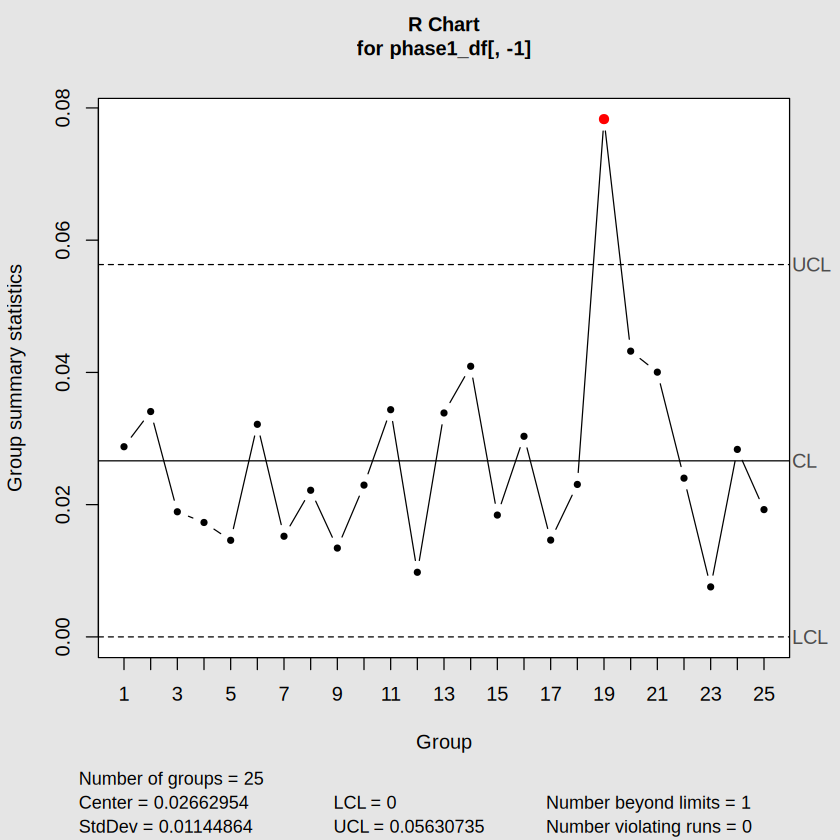

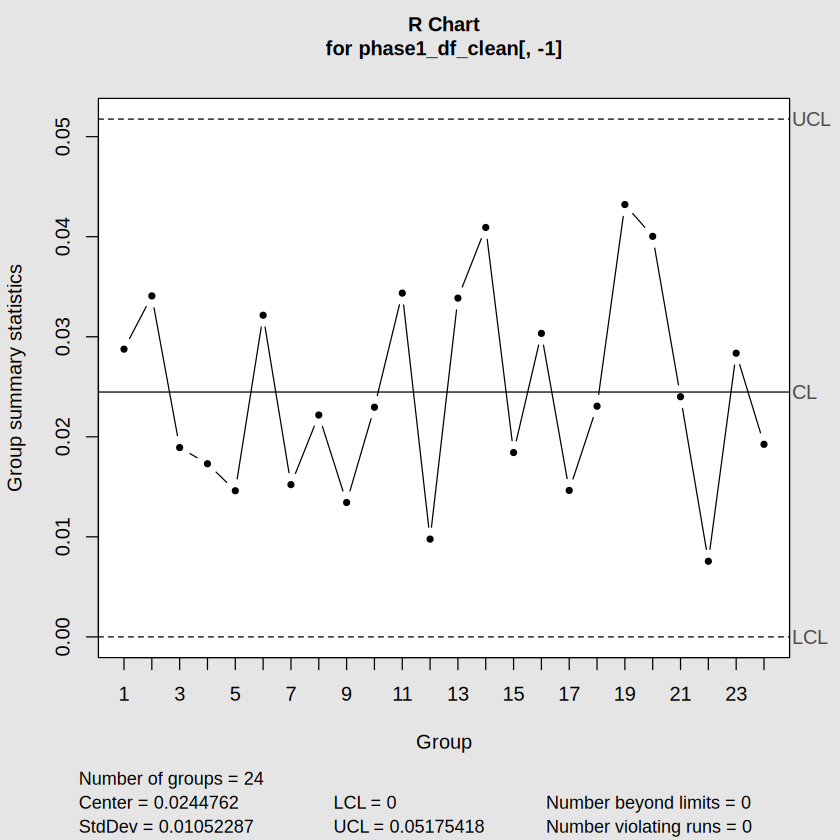

In [17]:
phase1_R<-qcc(phase1_df[,-1],
                                  type= "R",
                                  plot= TRUE)

## Removal of Subgroup 19 ##
phase1_df_clean <- phase1_df |>
  filter(Subgroup !=19)

## Run without 19 ##
phase1_R_clean <-qcc(phase1_df_clean[,-1],
                                                type= "R",
                                                plot=TRUE)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

## A6: The initial Phase1 $\bar{X}$ was not in statistical control. Subgroup 12 fell above the Upper Control Limits of 1.767736 mm. This showed that the mean filament diamter for Subgroup 12 was high. Again, A possible cause could be the inconsistent performance of the heating element on Extruder Line 3. This possible issue with the heating element may have caused the diameter of the filament to move above its normal process mean. I then removed Subgroup 12, creating another cleaned dataset and recalculated the control limits. The remaining Subgroups fall within the new control limits. The UCL is 1.765879 mm and the LCL is 1.736905. With the remaining data we can now show statistical control within the process mean. I am seeing signs of violating runs.

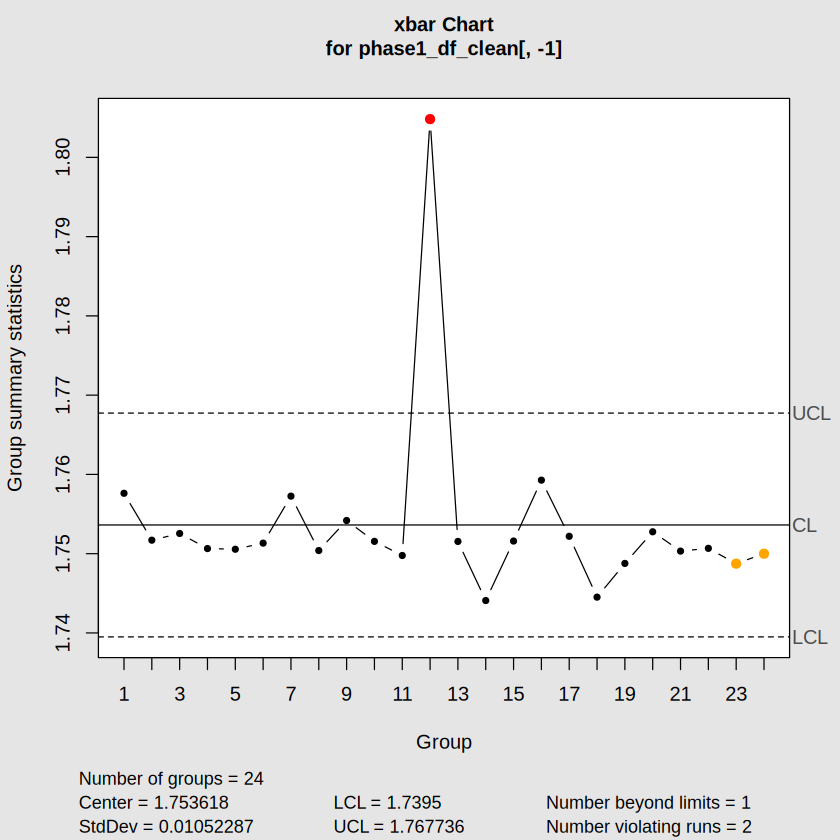

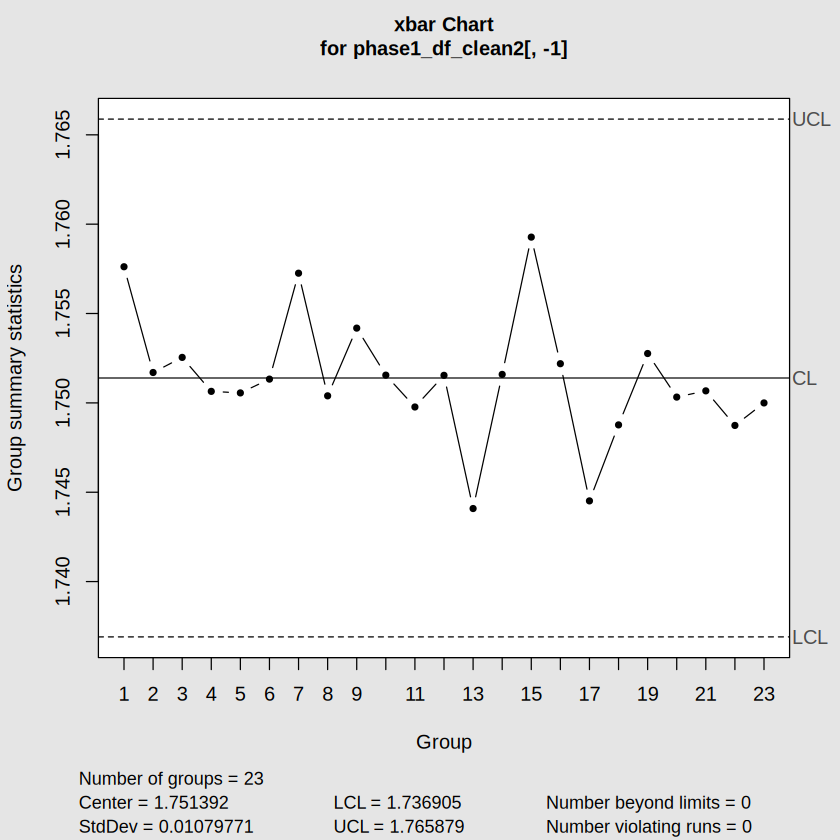

In [18]:
phase1_xbar_clean <-qcc(phase1_df_clean[,-1],
                                                  type= "xbar",
                                                  plot = TRUE)

phase1_df_clean2<- phase1_df_clean |>
  filter(Subgroup !=12)

phase1_xbar_clean2 <- qcc(phase1_df_clean2[,-1],
                                                     type = "xbar",
                                                     plot = TRUE)

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

## A8: Now using the  method, the estimated process mean for the original Phase 1 data is 1.754017 mm and the estimated process standard deviation is approximately 0.01144864 mm. The initial Phase 1 s chart was not in statistical control. Subgroup 19 again exceeded the upper control limit of 0.02266979 indicating high variablity in the dimater of the filament. A possible cause again could be the inconsistent performance of the aging heating element in Extruder 3. After removing Subgroup 19 and completing the s chart again, the remaining Subgroups fell within the statistical control limits.
## Using the cleaned data, the $\bar{X}$ chart was also not in statistical control. Subgroup 12 again was exceeding the UCL of 1.767736 mm which meant a high filament diameter. Again, the ageing heating element in Extruder Line 3 could be the cause. By removing Subgroup 12 and doing the chart a second time, the remaining Subgroup s fell within the UCL of 1.765879 mm and LCL of 1.736905 mm with no violating runs. The remaining Subgroups data shows statistical control using the s method.

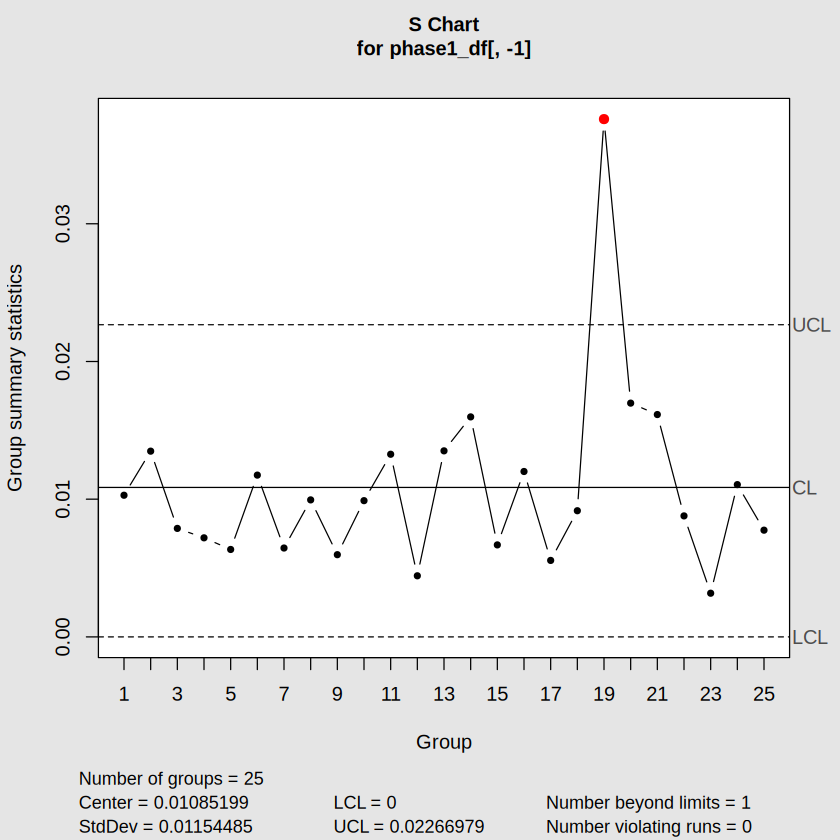

[1] 0.01052287

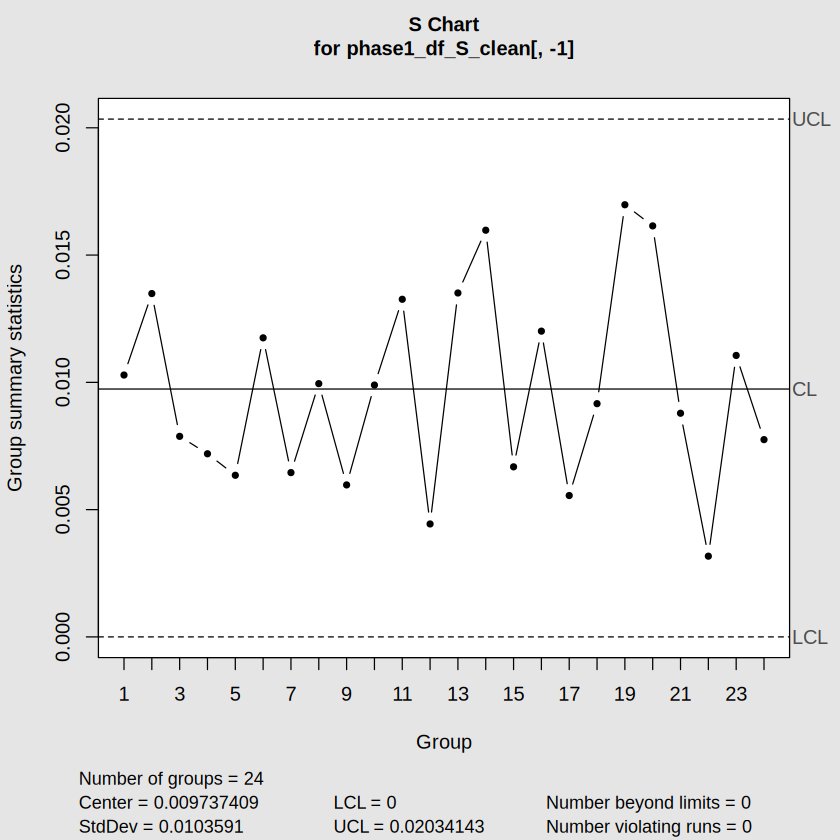

[1] 0.01079771

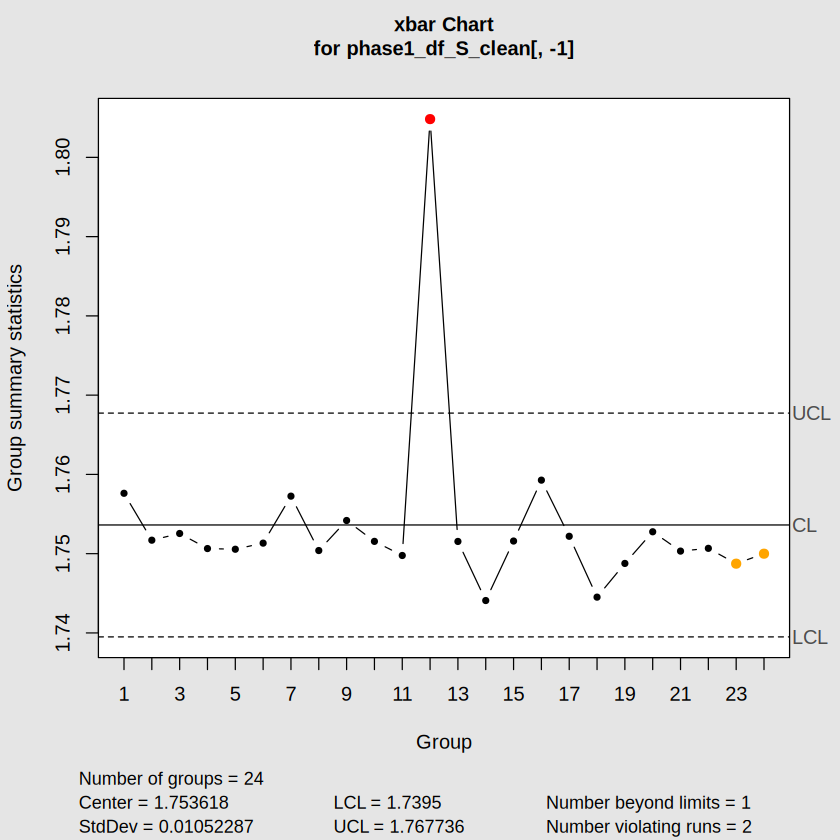

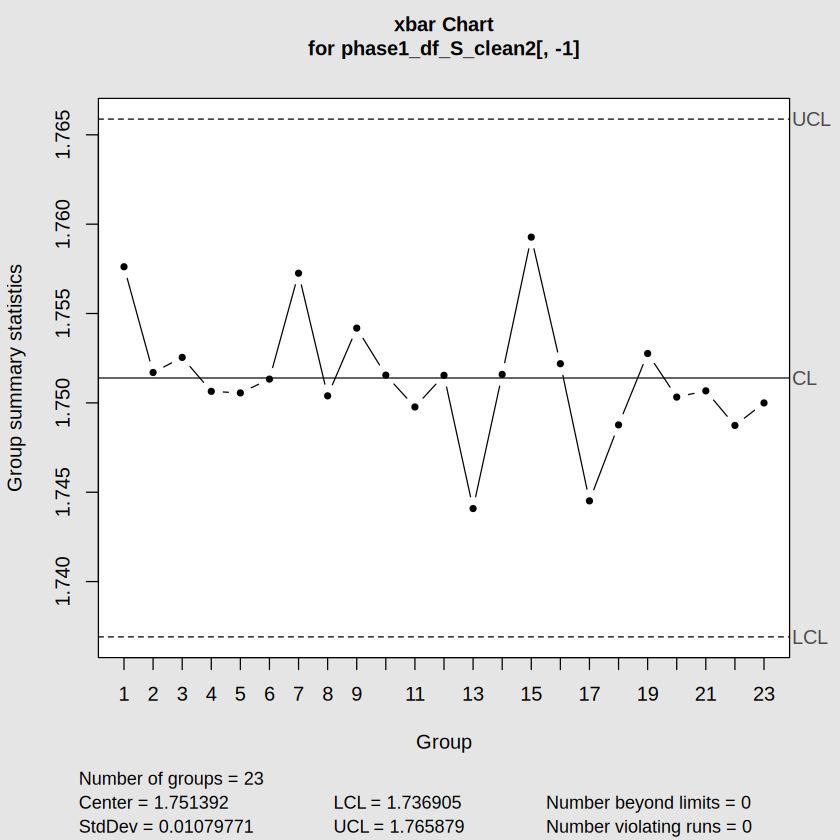

In [19]:
phase1_S <-qcc(phase1_df[,-1],
                                   type= "S",
                                   plot= TRUE)

## SUBgroup 19 is not in statistical control so remove ##

phase1_df_S_clean <- phase1_df |>
  filter(Subgroup !=19)

## ReDo without 19 ##
phase1_S_clean<-qcc(phase1_df_S_clean[,-1],
                                                type= "S",
                                                plot= TRUE)

## Now using s ##
sig_hat_S <- sd.xbar(phase1_df_S_clean[,-1])
sig_hat_S

phase1_xbar_S <- qcc(phase1_df_S_clean[,-1],
                                                  type = "xbar",
                                                  std.dev= sig_hat_S,
                                                  plot= TRUE)

## Subgroup 12 is a violation so needs to be removed ##
phase1_df_S_clean2 <-phase1_df_S_clean |>
  filter(Subgroup !=12)

## Std Dev again with s ##
sig_hat_S2 <-sd.xbar(phase1_df_S_clean2[,-1])
sig_hat_S2

## Xbar chart ##
phase1_xbar_S_clean <- qcc(phase1_df_S_clean2[,-1],
                                                        type="xbar",
                                                        std.dev = sig_hat_S2,
                                                        plot= TRUE)

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

##A8: Using the final Phase I estimates of the process mean and process standard deviation using the $s$ method.The process capability analysis against the specification limits given above produced the following results. The $FNC$ resulted in an output of approximately 0%, $C_p$ = 1.544, $C_{pk}$ = 1.501, and $C_{pm}$ = 1.531. They are all above 1 and the process is capable of meeting the specification limits of 1.700 mm to 1.800 mm/ The estimated process mean of 1.751392 mm is also very close to the target diamter of 1.750 mm. The slightly lower $C_{pk}$ compared to the $C_p$ tells us that the process is not perfectly centered though the small difference between the process mean and target tells us that is is still well-centered.

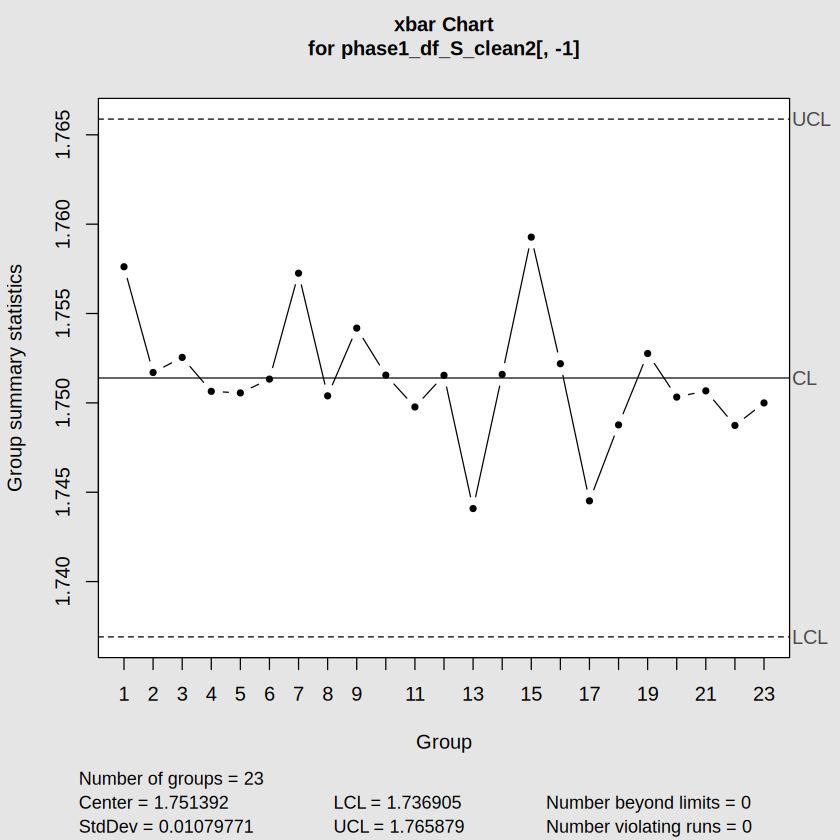


Process Capability Analysis

Call:
process.capability(object = p1x, spec.limits = c(1.7, 1.8), target = 1.75,     nsigmas = 3)

Number of obs = 115          Target = 1.75
       Center = 1.751           LSL = 1.7
       StdDev = 0.0108          USL = 1.8

Capability indices:

      Value   2.5%  97.5%
Cp    1.544  1.343  1.743
Cp_l  1.587  1.406  1.767
Cp_u  1.501  1.329  1.672
Cp_k  1.501  1.296  1.705
Cpm   1.531  1.332  1.730

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 0%	 Obs>USL 0%


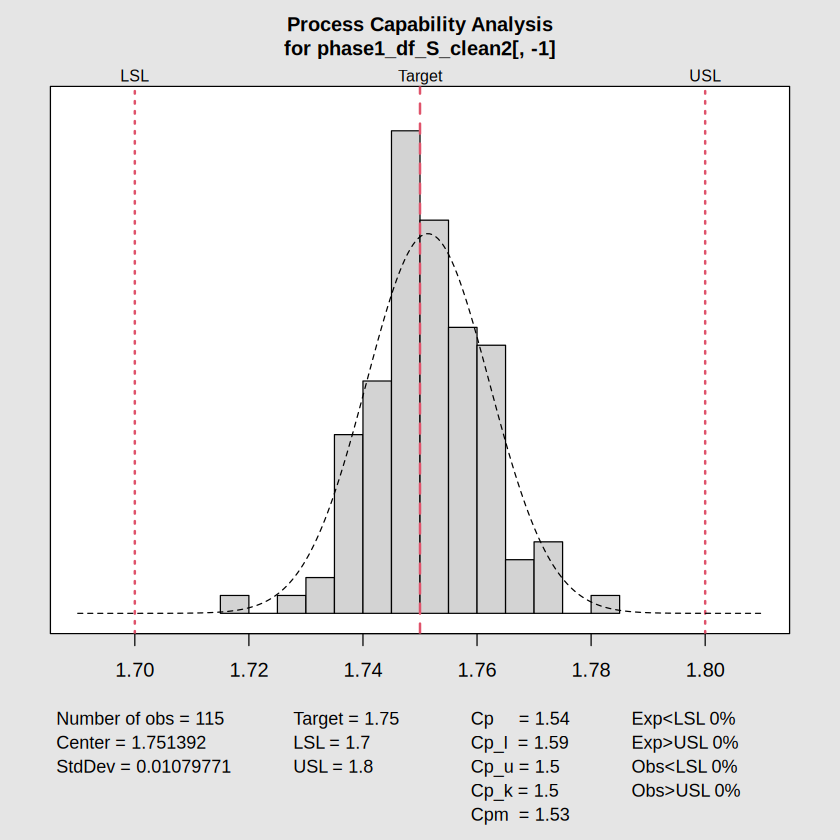

In [20]:
## Final Phase 1 and perform a process capability analysis ###
p1x <- qcc(phase1_df_S_clean2[,-1],
                                        type="xbar",
                                        std.dev= sig_hat_S2,
                                        plot= TRUE)

## Analysis ##
process.capability(p1x,
                   spec.limits = c(1.700, 1.800),
                   target= 1.750,
                   nsigmas = 3)

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

## A9: Leaving the OCC points in the Phase I calculations of the control limts is not advisable because it woud be building error into the control limits from the start. The OCC points do not represent normal operations and could skew the estimates of the process mean and variability. By removing the points and recalculating we are able to see a better process when in statistical control.



## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

## A10: Using the finalized Phase I center line and control limits from Q7, none of the Subgroups plot outside the control limits of 1.736905mm(LCL) and 1.765879mm(UCL). The chart tells us Number beyond limits=0. I am observing 7 violating runs in the later subgroups(14-20).

Rows: 20
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.741281, 1.752716, 1.757787, 1.750684, 1.750781, 1.746839, 1…
$ Meas2    <dbl> 1.755570, 1.752597, 1.749910, 1.739595, 1.750607, 1.758723, 1…
$ Meas3    <dbl> 1.754157, 1.748972, 1.755079, 1.747991, 1.750896, 1.751448, 1…
$ Meas4    <dbl> 1.754749, 1.749849, 1.747444, 1.749558, 1.754583, 1.752087, 1…
$ Meas5    <dbl> 1.733665, 1.745653, 1.756482, 1.756971, 1.750307, 1.744185, 1…


List of 11
 $ call      : language qcc(data = phase2data[, -1], type = "xbar", center = xbar_center, limits = xbar_lims,      plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "phase2data[, -1]"
 $ data      : num [1:20, 1:5] 1.74 1.75 1.76 1.75 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 1.75 1.75 1.75 1.75 1.75 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 1.75
 $ std.dev   : num 0.00606
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 1.74 1.77
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

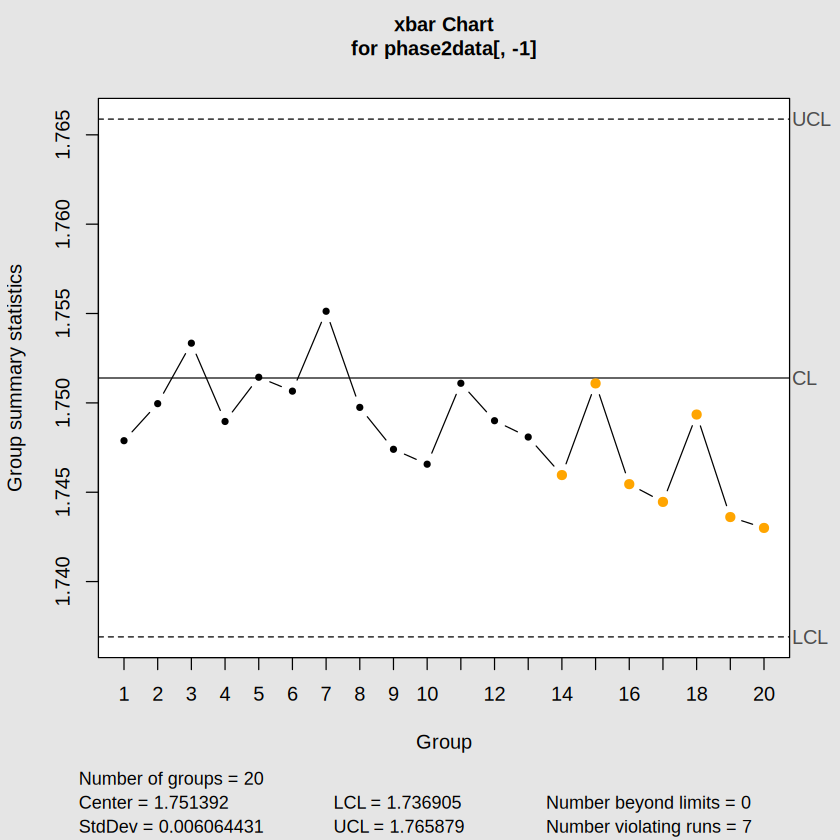

In [21]:
## Read IN ##
phase2data<-read_excel("FilamentDiameter_PhaseII.xlsx")

##Check##
phase2data|>
  glimpse()

##Xbar chart##

xbar_lims<-qcc(phase1_df_S_clean2[,-1],type="xbar",std.dev=sig_hat_S2,
               plot=FALSE)$limits

xbar_center <-qcc(phase1_df_S_clean2[,-1],type="xbar",std.dev=sig_hat_S2,
                  plot=FALSE)$center

qcc(phase2data[,-1],
    type="xbar",
    center=xbar_center,
    limits=xbar_lims,
    plot=TRUE)

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

## A11: None of the Subgroups plot outside of the control limits of 0mm(LCL) and 0.021021mm(UCL). Most of the subgroups fell below the center line of 0.009968 mm. This tells me that process variablity may be decreasing.

List of 11
 $ call      : language qcc(data = phase2data[, -1], type = "S", center = s_center, limits = s_lims,      plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "phase2data[, -1]"
 $ data      : num [1:20, 1:5] 1.74 1.75 1.76 1.75 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 0.00989 0.00292 0.00445 0.00625 0.00177 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.00997
 $ std.dev   : num 0.00625
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.021
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

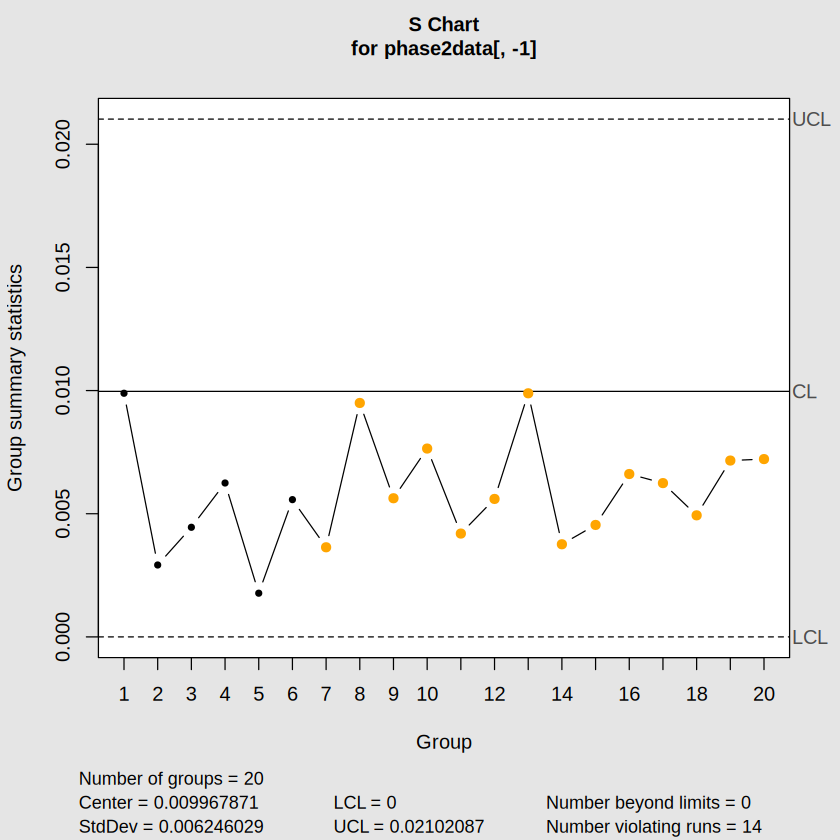

In [22]:
## Phase II $S$ chart ##
##Xbar chart##

s_lims<-qcc(phase1_df_S_clean2[,-1],type="S",std.dev=sig_hat_S2,
               plot=FALSE)$limits

s_center <-qcc(phase1_df_S_clean2[,-1],type="S",std.dev=sig_hat_S2,
                  plot=FALSE)$center

qcc(phase2data[,-1],
    type="S",
    center=s_center,
    limits=s_lims,
    plot=TRUE)

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

## A12: Overall, I would say that Extruder Line 3 does not need to be completely overhauled. During our initial Phase 1 data I found that subgroup 19 and 12 were out of control subgroups and removed. After removing the subgroups the process was in statistical control.

After I ran a process capability analysis that again showed that Extruder Line 3 is functioning within the required specifications. The process is relatively well-centered around the goal diameter of 1.750mm. This was shown with the analysis results of $C_p$=1.544, a $C_{pk}$= 1.501 and a $C_{pm}$=1.531 and nonconforming of approximately 0%.

During the Phase 2 review, no subgroups fell outside the control limits in either the $\bar{X}$ or $s$ chart. This was a good sign. With that being said, these charts also showed violating runs fairly consistently running below their center line. This tells me that although the filament diameter is still meeting specifications there may be a shift occuring even without the individual subgroups that were outside of limits.

I would recommend investigating Extruder Line 3 before completely overhauling it. The line is still producing within the 1.700 and 1.800 specifications. These results are showing us that continued monitoring and maintenance(including the heating element) are needed before a major investment.